In [ ]:
import torch
X = torch.arange(12,dtype = torch.float32).reshape(3,4)
Y = torch.tensor([[2.0,1,4,3],
                 [1,2,3,4],
                 [4,3,2,1]])
torch.cat((X,Y),dim=0),torch.cat((X,Y),dim=1)

(tensor([[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.],
         [ 2.,  1.,  4.,  3.],
         [ 1.,  2.,  3.,  4.],
         [ 4.,  3.,  2.,  1.]]),
 tensor([[ 0.,  1.,  2.,  3.,  2.,  1.,  4.,  3.],
         [ 4.,  5.,  6.,  7.,  1.,  2.,  3.,  4.],
         [ 8.,  9., 10., 11.,  4.,  3.,  2.,  1.]]))

In [7]:
Z = torch.zeros_like(Y)
print('id(Z): ',id(Z))
Z[:] = X+ Y 
print('id(Z): ',id(Z))

id(Z):  1976548324784
id(Z):  1976548324784


In [ ]:
import torch

# 1. 创建一个形状为(4,5)的二维张量
a = torch.arange(20).reshape(4, 5)
print("Step 1: a =\n", a)

# 2. 提取a的第2行(索引为1)
row_2 = a[1]
print("Step 2: 第2行 (索引为1) =\n", row_2)

# 3. 提取a的第1到第3行、第2到第4列的子张量
sub_tensor = a[0:3, 1:4]
print("Step 3: 第1到第3行，第2到第4列 =\n", sub_tensor)

# 4. 将a中所有大于10的元素替换为 -1
a[a > 10] = -1
print("Step 4: 将大于10的元素替换为 -1 =\n", a)

# 5. 将a的形状转换为 (2,2,5)
a_reshaped = a.reshape(2, 2, 5)
print("Step 5: 形状转换为 (2,2,5) =\n", a_reshaped)


Step 1: a =
 tensor([[ 0,  1,  2,  3,  4],
        [ 5,  6,  7,  8,  9],
        [10, 11, 12, 13, 14],
        [15, 16, 17, 18, 19]])
Step 2: 第2行 (索引为1) =
 tensor([5, 6, 7, 8, 9])
Step 3: 第1到第3行，第2到第4列 =
 tensor([[ 1,  2,  3],
        [ 6,  7,  8],
        [11, 12, 13]])
Step 4: 将大于10的元素替换为 -1 =
 tensor([[ 0,  1,  2,  3,  4],
        [ 5,  6,  7,  8,  9],
        [10, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1]])
Step 5: 形状转换为 (2,2,5) =
 tensor([[[ 0,  1,  2,  3,  4],
         [ 5,  6,  7,  8,  9]],

        [[10, -1, -1, -1, -1],
         [-1, -1, -1, -1, -1]]])


In [3]:
import torch

# 1. 创建张量 a 和 b
a = torch.tensor([[1], [2], [3]])  # 注意 a 是列向量
b = torch.tensor([10, 20, 30])    # b 是行向量

# 2. 利用广播机制计算 a + b
result = a + b
print("Step 2: a + b =\n", result)

# 3. 提取结果张量中的第 1 行和第 3 列元素
row_1 = result[0]  # 第 1 行
col_3 = result[:, 2]  # 第 3 列
print("Step 3: 第 1 行 =\n", row_1)
print("Step 3: 第 3 列 =\n", col_3)

# 4. 将结果张量转为一维
result_flattened = result.reshape(-1)
print("Step 4: 转为一维 =\n", result_flattened)

# 5. 将结果逆序排列
result_reversed = result_flattened.flip(dims=[0])
print("Step 5: 逆序排列 =\n", result_reversed)

Step 2: a + b =
 tensor([[11, 21, 31],
        [12, 22, 32],
        [13, 23, 33]])
Step 3: 第 1 行 =
 tensor([11, 21, 31])
Step 3: 第 3 列 =
 tensor([31, 32, 33])
Step 4: 转为一维 =
 tensor([11, 21, 31, 12, 22, 32, 13, 23, 33])
Step 5: 逆序排列 =
 tensor([33, 23, 13, 32, 22, 12, 31, 21, 11])


d:\Anaconda\envs\pytorch\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 32593 (\N{CJK UNIFIED IDEOGRAPH-7F51}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\envs\pytorch\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 32476 (\N{CJK UNIFIED IDEOGRAPH-7EDC}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


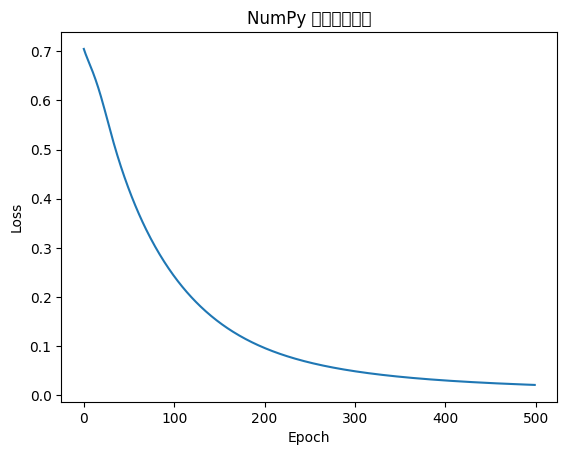

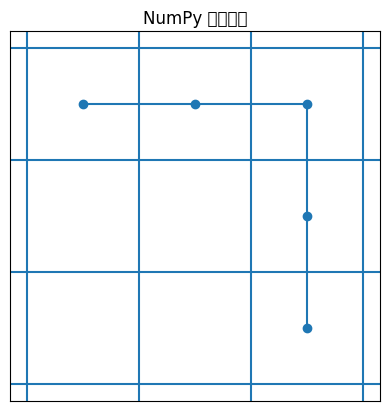

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ========== 版本1：纯 NumPy 实现神经网络 ==========

# 数据集：九宫格路径上的状态（坐标）与动作标签（0=向右，1=向下）
X = np.array([[0, 0], [0, 1], [0, 2], [1, 2]], dtype=np.float32)
y = np.array([0, 0, 1, 1], dtype=np.int32)

# 网络超参数
input_size, hidden_size, output_size = 2, 16, 2
lr = 0.1
epochs = 500

# 参数初始化
W1 = np.random.randn(input_size, hidden_size) * 0.1
b1 = np.zeros(hidden_size)
W2 = np.random.randn(hidden_size, output_size) * 0.1
b2 = np.zeros(output_size)

# 激活与辅助函数
def relu(x): return np.maximum(0, x)
def drelu(x): return (x > 0).astype(np.float32)
def softmax(x):
    e = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e / np.sum(e, axis=1, keepdims=True)

# 训练记录
loss_list_np = []
acc_list_np = []

# 训练循环
for epoch in range(epochs):
    # 前向传播
    h = relu(X.dot(W1) + b1)
    logits = h.dot(W2) + b2
    probs = softmax(logits)
    # 交叉熵损失
    loss = -np.mean(np.log(probs[np.arange(len(X)), y]))
    loss_list_np.append(loss)
    # 计算准确率
    preds = np.argmax(probs, axis=1)
    acc_list_np.append((preds == y).mean())
    # 反向传播
    dlogits = probs
    dlogits[np.arange(len(X)), y] -= 1
    dlogits /= len(X)
    dW2 = h.T.dot(dlogits)
    db2 = dlogits.sum(axis=0)
    dh = dlogits.dot(W2.T) * drelu(h)
    dW1 = X.T.dot(dh)
    db1 = dh.sum(axis=0)
    # 参数更新
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

# 用训练好的网络模拟最短路径
pos = [0, 0]
path_np = [tuple(pos)]
while tuple(pos) != (2, 2):
    x = np.array(pos, dtype=np.float32).reshape(1, 2)
    h = relu(x.dot(W1) + b1)
    logits = h.dot(W2) + b2
    move = np.argmax(logits)
    if move == 0:
        pos[1] += 1
    else:
        pos[0] += 1
    path_np.append(tuple(pos))

# 绘制 NumPy 网络训练损失
plt.figure()
plt.plot(loss_list_np)
plt.title('NumPy 网络训练损失')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

# 绘制 NumPy 模型最短路径
plt.figure()
for i in range(4):
    plt.axvline(i)
    plt.axhline(i)
xs = [p[1] + 0.5 for p in path_np]
ys = [3 - p[0] - 0.5 for p in path_np]
plt.plot(xs, ys, marker='o')
plt.title('NumPy 最短路径')
plt.xticks([]); plt.yticks([]); plt.gca().set_aspect('equal')
plt.show()




d:\Anaconda\envs\pytorch\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 32593 (\N{CJK UNIFIED IDEOGRAPH-7F51}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\envs\pytorch\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 32476 (\N{CJK UNIFIED IDEOGRAPH-7EDC}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\envs\pytorch\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\envs\pytorch\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\envs\pytorch\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from current font.
  fig.canvas.print_figure(bytes_

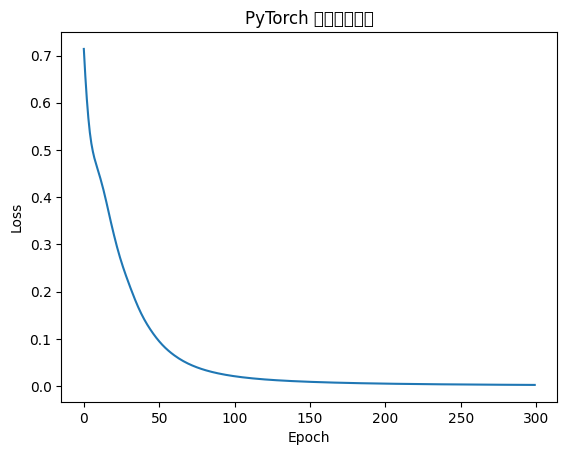

d:\Anaconda\envs\pytorch\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\envs\pytorch\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 30701 (\N{CJK UNIFIED IDEOGRAPH-77ED}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\envs\pytorch\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 36335 (\N{CJK UNIFIED IDEOGRAPH-8DEF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\envs\pytorch\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24452 (\N{CJK UNIFIED IDEOGRAPH-5F84}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


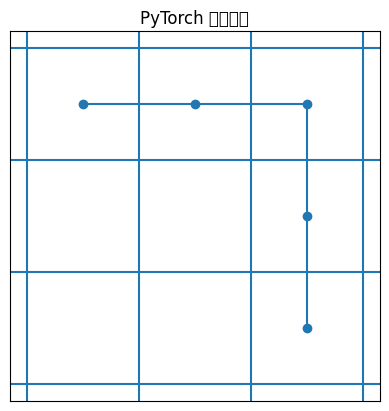

In [4]:
# ========== 版本2：基于 PyTorch 实现神经网络 ==========

import torch
import torch.nn as nn
import torch.optim as optim

# 数据集
X_t = torch.tensor([[0, 0], [0, 1], [0, 2], [1, 2]], dtype=torch.float32)
y_t = torch.tensor([0, 0, 1, 1], dtype=torch.long)

# 模型定义
model = nn.Sequential(
    nn.Linear(2, 16),
    nn.ReLU(),
    nn.Linear(16, 2)
)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 训练记录
loss_list_torch = []

# 训练循环
for epoch in range(300):
    optimizer.zero_grad()
    outputs = model(X_t)
    loss = criterion(outputs, y_t)
    loss.backward()
    optimizer.step()
    loss_list_torch.append(loss.item())

# 用训练好的 PyTorch 模型模拟最短路径
pos = [0, 0]
path_t = [tuple(pos)]
with torch.no_grad():
    while tuple(pos) != (2, 2):
        x = torch.tensor([pos], dtype=torch.float32)
        out = model(x)
        move = out.argmax(dim=1).item()
        if move == 0:
            pos[1] += 1
        else:
            pos[0] += 1
        path_t.append(tuple(pos))

# 绘制 PyTorch 网络训练损失
plt.figure()
plt.plot(loss_list_torch)
plt.title('PyTorch 网络训练损失')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

# 绘制 PyTorch 模型最短路径
plt.figure()
for i in range(4):
    plt.axvline(i)
    plt.axhline(i)
xs = [p[1] + 0.5 for p in path_t]
ys = [3 - p[0] - 0.5 for p in path_t]
plt.plot(xs, ys, marker='o')
plt.title('PyTorch 最短路径')
plt.xticks([]); plt.yticks([]); plt.gca().set_aspect('equal')
plt.show()
